# Mass–Spring–Damper Interactive Response
This notebook simulates a discrete mass–spring–damper system and provides an interactive live plot of the displacement over time. Use the sliders to change `m`, `c`, `k`, initial displacement and velocity, then press Play to scan through the response.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets

def simulate(ms, c, k, x0, v0, dt=0.01, t_end=10.0):
    n = int(np.floor(t_end/dt)) + 1
    t = np.linspace(0.0, (n-1)*dt, n)
    x = np.zeros(n)
    v = np.zeros(n)
    x[0] = x0
    v[0] = v0
    if ms <= 0:
        raise ValueError('Mass must be > 0')
    for i in range(n-1):
        a = (-c * v[i] - k * x[i]) / ms
        v[i+1] = v[i] + a * dt
        x[i+1] = x[i] + v[i+1] * dt
    return t, x, v

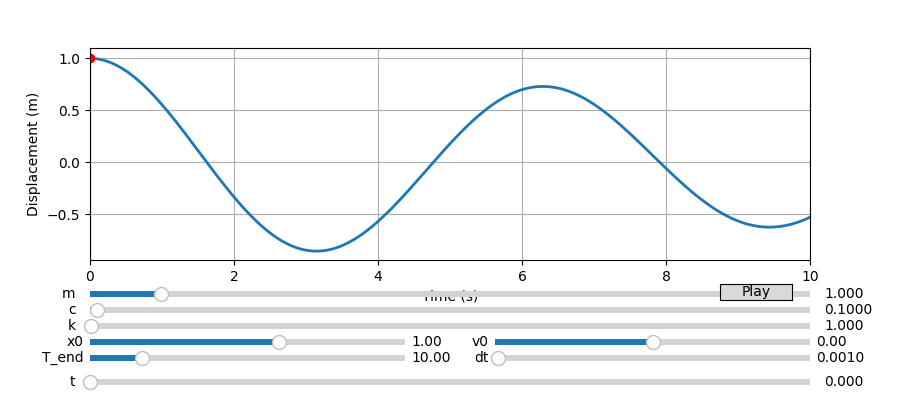

RuntimeError: Another Axes already grabs mouse input

RuntimeError: Another Axes already grabs mouse input

RuntimeError: Another Axes already grabs mouse input

RuntimeError: Another Axes already grabs mouse input

In [3]:
# Interactive UI: matplotlib widget-based controls (no ipywidgets)
%matplotlib widget
import matplotlib.animation as animation
from matplotlib.widgets import Slider, Button

# initial parameters
ms0 = 1.0
c0 = 0.1
k0 = 1.0
x0_0 = 1.0
v0_0 = 0.0
dt0 = 0.001
tend0 = 10.0

# reuse simulate(ms, c, k, x0, v0, dt, t_end) defined earlier
t, x, v = simulate(ms0, c0, k0, x0_0, v0_0, dt=dt0, t_end=tend0)

fig, ax = plt.subplots(figsize=(9,4))
plt.subplots_adjust(left=0.1, bottom=0.35)
line_x, = ax.plot(t, x, lw=2)
vline = ax.axvline(t[0], color='r')
point, = ax.plot(t[0], x[0], 'ro')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement (m)')
ax.set_xlim(0, t[-1])
ax.set_ylim(x.min() - 0.1 * abs(x.min()), x.max() + 0.1 * abs(x.max()))
ax.grid(True)

# slider axes
ax_m = plt.axes([0.1, 0.25, 0.8, 0.03])
ax_c = plt.axes([0.1, 0.21, 0.8, 0.03])
ax_k = plt.axes([0.1, 0.17, 0.8, 0.03])
ax_x0 = plt.axes([0.1, 0.13, 0.35, 0.03])
ax_v0 = plt.axes([0.55, 0.13, 0.35, 0.03])
ax_tend = plt.axes([0.1, 0.09, 0.35, 0.03])
ax_dt = plt.axes([0.55, 0.09, 0.35, 0.03])
ax_time = plt.axes([0.1, 0.03, 0.8, 0.03])

s_m = Slider(ax_m, 'm', 0.01, 10.0, valinit=ms0, valfmt='%.3f')
s_c = Slider(ax_c, 'c', 0.0, 10.0, valinit=c0, valfmt='%.4f')
s_k = Slider(ax_k, 'k', 0.01, 1000.0, valinit=k0, valfmt='%.3f')
s_x0 = Slider(ax_x0, 'x0', -5.0, 5.0, valinit=x0_0, valfmt='%.2f')
s_v0 = Slider(ax_v0, 'v0', -10.0, 10.0, valinit=v0_0, valfmt='%.2f')
s_tend = Slider(ax_tend, 'T_end', 0.1, 60.0, valinit=tend0, valfmt='%.2f')
s_dt = Slider(ax_dt, 'dt', 1e-4, 1e-1, valinit=dt0, valfmt='%1.4f')
s_time = Slider(ax_time, 't', 0.0, t[-1], valinit=0.0, valfmt='%.3f')

playing = {'state': False, 'frame': 0}

def update_simulation(val=None):
    global t, x, v, s_time
    ms = float(s_m.val)
    c = float(s_c.val)
    k = float(s_k.val)
    x0 = float(s_x0.val)
    v0 = float(s_v0.val)
    dt = float(s_dt.val)
    t_end = float(s_tend.val)
    t, x, v = simulate(ms, c, k, x0, v0, dt=dt, t_end=t_end)
    line_x.set_xdata(t)
    line_x.set_ydata(x)
    ax.set_xlim(0, t[-1])
    ax.set_ylim(x.min() - 0.1 * abs(x.min()), x.max() + 0.1 * abs(x.max()))
    # recreate time slider to match new t range
    s_time.ax.clear()
    s_time = Slider(s_time.ax, 't', 0.0, t[-1], valinit=0.0, valfmt='%.3f')
    s_time.on_changed(on_time_changed)
    fig.canvas.draw_idle()

def on_time_changed(val):
    tv = val
    idx = int(np.clip(np.searchsorted(t, tv), 0, len(t)-1))
    vline.set_xdata([t[idx], t[idx]])
    point.set_data(t[idx], x[idx])
    fig.canvas.draw_idle()

s_m.on_changed(update_simulation)
s_c.on_changed(update_simulation)
s_k.on_changed(update_simulation)
s_x0.on_changed(update_simulation)
s_v0.on_changed(update_simulation)
s_tend.on_changed(update_simulation)
s_dt.on_changed(update_simulation)
s_time.on_changed(on_time_changed)

# Buttons for play/pause
ax_play = plt.axes([0.8, 0.25, 0.08, 0.04])
btn_play = Button(ax_play, 'Play')

def play_clicked(event):
    if not playing['state']:
        playing['state'] = True
        btn_play.label.set_text('Pause')
        start_animation()
    else:
        playing['state'] = False
        btn_play.label.set_text('Play')

btn_play.on_clicked(play_clicked)

def start_animation():
    # use the GUI timer to run on the main thread (works with ipympl)
    if not playing.get('timer'):
        playing['timer'] = fig.canvas.new_timer(interval=50)
        def on_timer():
            if not playing['state']:
                return
            playing['frame'] = (playing['frame'] + 1) % len(t)
            tt = t[playing['frame']]
            s_time.set_val(tt)
        playing['timer'].add_callback(on_timer)
    playing['timer'].start()

plt.show()